In [71]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import re
import itertools
import sys

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score

In [72]:
df = pd.read_csv(
    "adult.csv",          
    engine="python",
    on_bad_lines="skip",
)

print(df.shape)
print(df.head())

(32561, 15)
   age workclass  fnlwgt     education  education.num marital.status  \
0   90         ?   77053       HS-grad              9        Widowed   
1   82   Private  132870       HS-grad              9        Widowed   
2   66         ?  186061  Some-college             10        Widowed   
3   54   Private  140359       7th-8th              4       Divorced   
4   41   Private  264663  Some-college             10      Separated   

          occupation   relationship   race     sex  capital.gain  \
0                  ?  Not-in-family  White  Female             0   
1    Exec-managerial  Not-in-family  White  Female             0   
2                  ?      Unmarried  Black  Female             0   
3  Machine-op-inspct      Unmarried  White  Female             0   
4     Prof-specialty      Own-child  White  Female             0   

   capital.loss  hours.per.week native.country income  
0          4356              40  United-States  <=50K  
1          4356              18  U

In [73]:
# Drop fnlwgt, education.num, capital.gain, capital.loss
# Income will be set as dataset label
df = df.drop(columns=['fnlwgt','education.num','capital.gain','capital.loss']) 

In [74]:
df.columns.tolist()

['age',
 'workclass',
 'education',
 'marital.status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'hours.per.week',
 'native.country',
 'income']

<Axes: xlabel='age', ylabel='Count'>

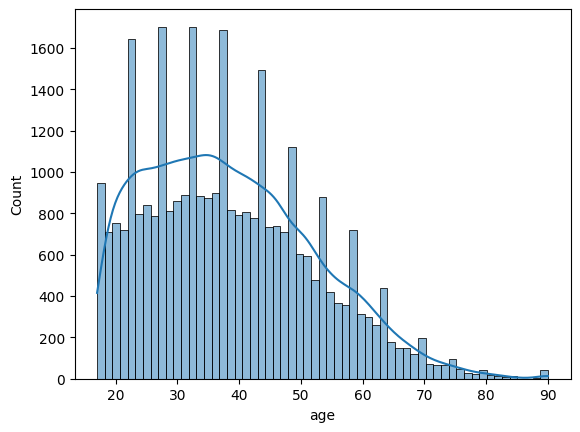

In [75]:
# Visualize dataset features
sns.histplot(data=df['age'], kde=True)

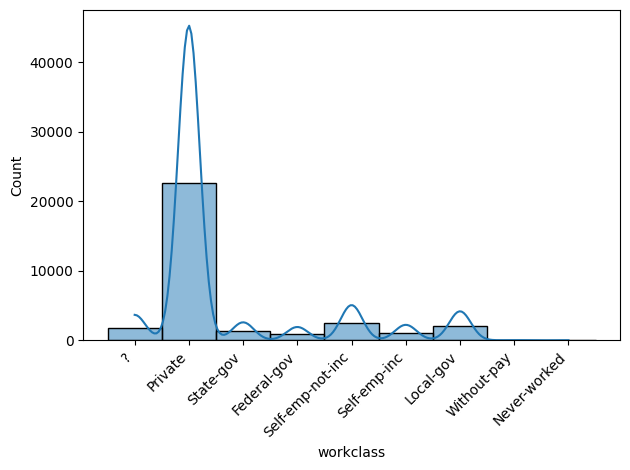

In [76]:
sns.histplot(data=df['workclass'], kde=True)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

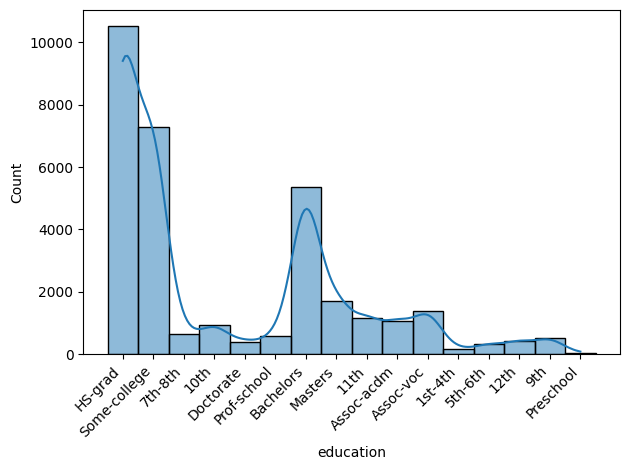

In [77]:
sns.histplot(data=df['education'], kde=True) 
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

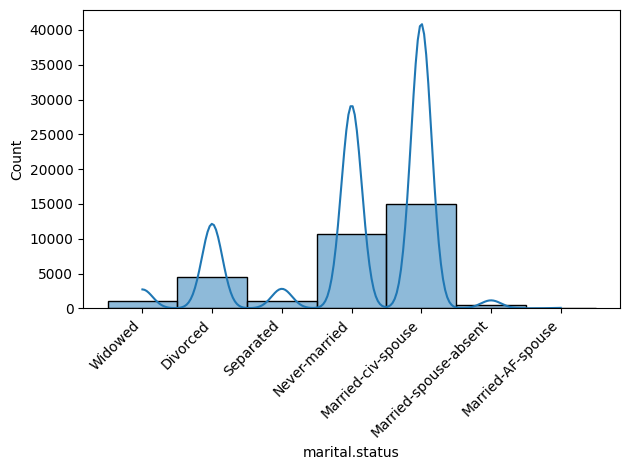

In [78]:
sns.histplot(data=df['marital.status'], kde=True) 
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

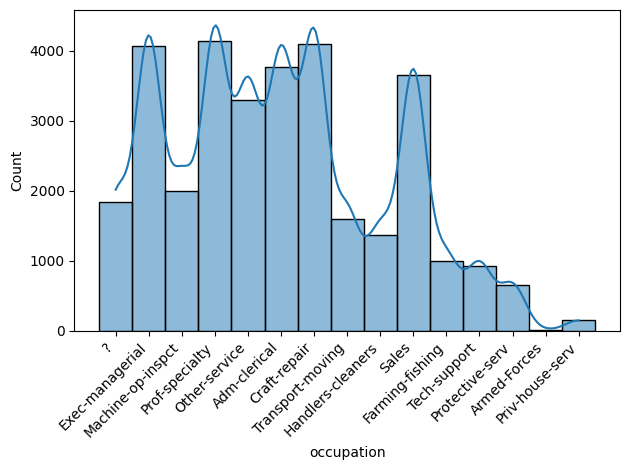

In [79]:
sns.histplot(data=df['occupation'], kde=True) 
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

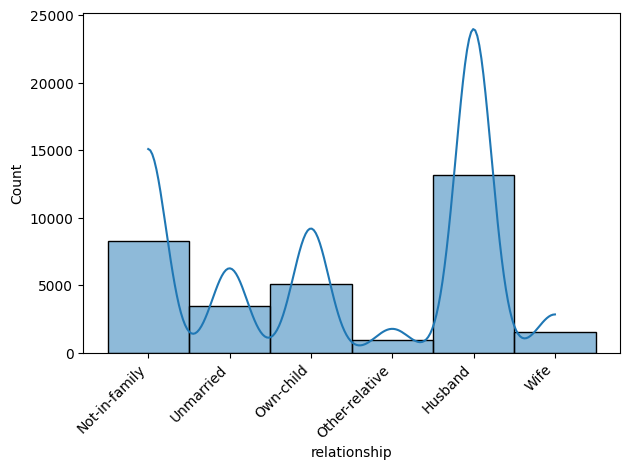

In [80]:
sns.histplot(data=df['relationship'], kde=True) 
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

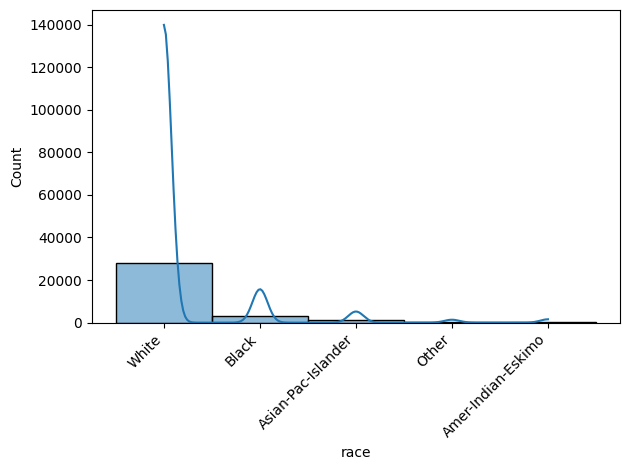

In [81]:
sns.histplot(data=df['race'], kde=True) 
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

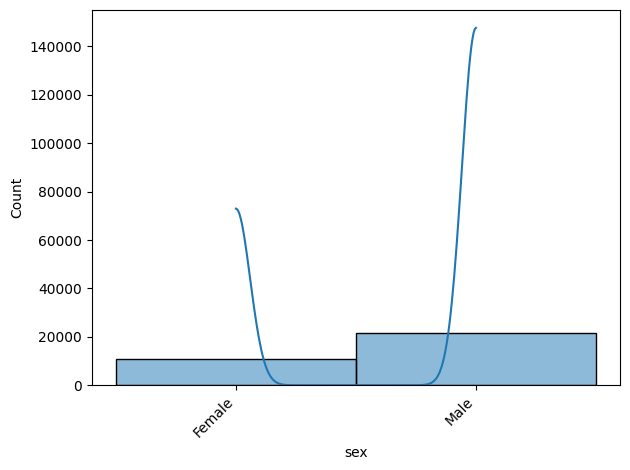

In [82]:
sns.histplot(data=df['sex'], kde=True) 
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

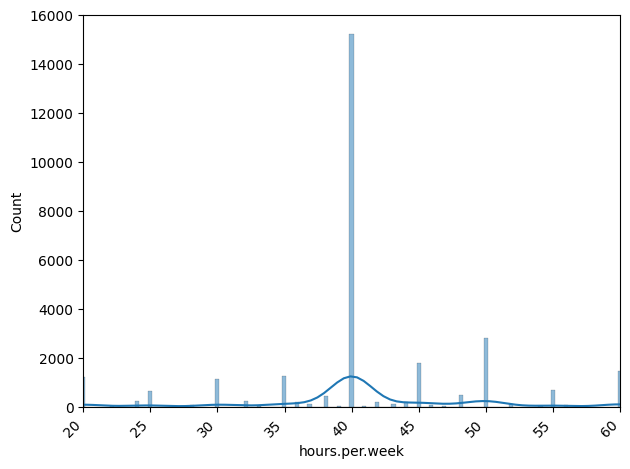

In [83]:
ax = sns.histplot(data=df['hours.per.week'], kde=True) 
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
ax.set_xlim(20, 60)
ax.set_ylim(0, 16000)
plt.show()

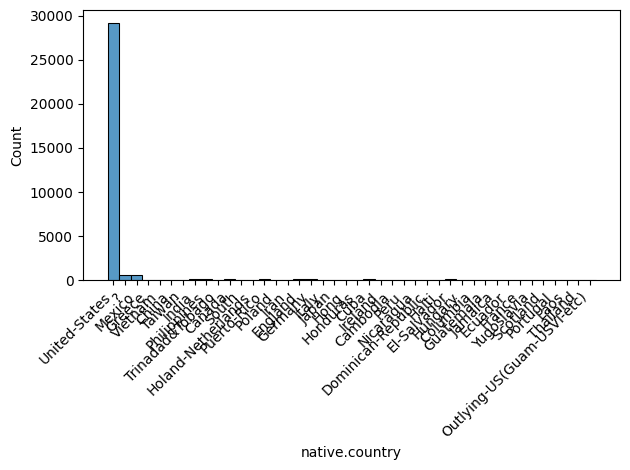

In [84]:
sns.histplot(data=df['native.country'], kde=False, discrete=True)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

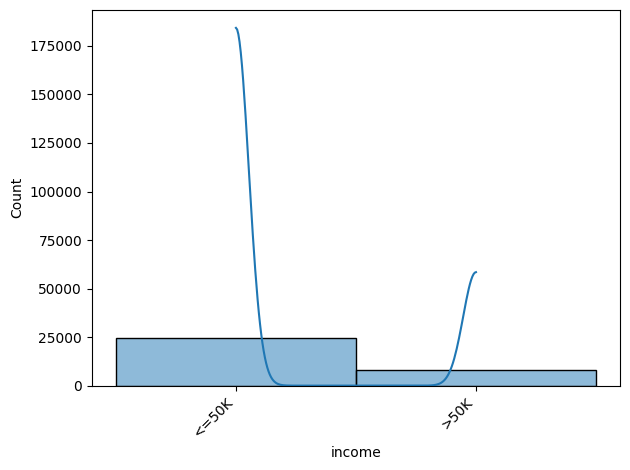

In [85]:
sns.histplot(data=df['income'], kde=True) 
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [86]:
df.isnull().sum()

age               0
workclass         0
education         0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
hours.per.week    0
native.country    0
income            0
dtype: int64

In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   education       32561 non-null  object
 3   marital.status  32561 non-null  object
 4   occupation      32561 non-null  object
 5   relationship    32561 non-null  object
 6   race            32561 non-null  object
 7   sex             32561 non-null  object
 8   hours.per.week  32561 non-null  int64 
 9   native.country  32561 non-null  object
 10  income          32561 non-null  object
dtypes: int64(2), object(9)
memory usage: 2.7+ MB


In [88]:
# Perform one hot encoding on object dtypes
df = pd.get_dummies(df, columns=["workclass"], drop_first=False)
df = pd.get_dummies(df, columns=["education"], drop_first=False)
df = pd.get_dummies(df, columns=["marital.status"], drop_first=False)
df = pd.get_dummies(df, columns=["occupation"], drop_first=False)
df = pd.get_dummies(df, columns=["relationship"], drop_first=False)
df = pd.get_dummies(df, columns=["race"], drop_first=False)
df = pd.get_dummies(df, columns=["sex"], drop_first=False)
df = pd.get_dummies(df, columns=["native.country"], drop_first=False)

In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Columns: 105 entries, age to native.country_Yugoslavia
dtypes: bool(102), int64(2), object(1)
memory usage: 3.9+ MB


In [90]:
print(df.columns.tolist())

['age', 'hours.per.week', 'income', 'workclass_?', 'workclass_Federal-gov', 'workclass_Local-gov', 'workclass_Never-worked', 'workclass_Private', 'workclass_Self-emp-inc', 'workclass_Self-emp-not-inc', 'workclass_State-gov', 'workclass_Without-pay', 'education_10th', 'education_11th', 'education_12th', 'education_1st-4th', 'education_5th-6th', 'education_7th-8th', 'education_9th', 'education_Assoc-acdm', 'education_Assoc-voc', 'education_Bachelors', 'education_Doctorate', 'education_HS-grad', 'education_Masters', 'education_Preschool', 'education_Prof-school', 'education_Some-college', 'marital.status_Divorced', 'marital.status_Married-AF-spouse', 'marital.status_Married-civ-spouse', 'marital.status_Married-spouse-absent', 'marital.status_Never-married', 'marital.status_Separated', 'marital.status_Widowed', 'occupation_?', 'occupation_Adm-clerical', 'occupation_Armed-Forces', 'occupation_Craft-repair', 'occupation_Exec-managerial', 'occupation_Farming-fishing', 'occupation_Handlers-cle

In [91]:
# Create 2^10 models to analyze label-feature relationship

In [92]:
x = df.drop('income',axis=1)
y = df['income']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, stratify=y, random_state=1)

In [93]:
# Random Forest Classifier

rf = Pipeline([
    ('scale', RobustScaler()),
    ('rf', RandomForestClassifier())
])

rf_param_grid = {
    # "rf__n_estimators": np.arange(start=10, stop=30, step=2),
    # "rf__max_depth": np.arange(start=2, stop=20),
    # "rf__min_samples_leaf": np.arange(start=1, stop=5),
    "rf__n_estimators": [50, 100],
    "rf__max_depth": [None, 10, 20],
    "rf__min_samples_leaf": [1, 2, 4],
}

rf_gscv = GridSearchCV(rf, rf_param_grid, cv=3)
rf_gscv.fit(x_train, y_train)
rf_gscv.best_params_
print("done")

done


In [94]:
rf_gscv.best_params_

{'rf__max_depth': None, 'rf__min_samples_leaf': 2, 'rf__n_estimators': 100}

In [95]:
# Group one hot encoded features together from xtrain
all_cols = x.columns.tolist() 
feature_groups = {}

for col in all_cols:
    m = re.match(r"^([^_]+)", col)  # get prefix before underscore
    if m:
        prefix = m.group(1)  # if one hot encoded feature 
    else:
        prefix = col        # numerical
    feature_groups.setdefault(prefix, []).append(col)


for k, v in feature_groups.items():
    print(k, ":", len(v), "cols")

age : 1 cols
hours.per.week : 1 cols
workclass : 9 cols
education : 16 cols
marital.status : 7 cols
occupation : 15 cols
relationship : 6 cols
race : 5 cols
sex : 2 cols
native.country : 42 cols


In [96]:
# Testing train on n = 1 feature subset
results = []
cols = [c for c in feature_groups['workclass']]
rf_gscv.fit(x_train[cols], y_train)
y_prob = rf_gscv.predict_proba(x_test[cols])[:, 1]
auc = roc_auc_score(y_test, y_prob)
results.append({
    "n_columns": len(cols),
    "auc": auc,
})
results

[{'n_columns': 9, 'auc': 0.5808109747876501}]

In [33]:
# Create 1024 models
group_names = list(feature_groups.keys())
results = []

for k in range(1, 11):
    for group_combo in itertools.combinations(group_names, k):
        cols = [c for g in group_combo for c in feature_groups[g]] # groupings -> one hot encoded vectors 
        rf_gscv.fit(x_train[cols], y_train)

        y_prob = rf_gscv.predict_proba(x_test[cols])[:, 1] 
        auc = roc_auc_score(y_test, y_prob) 

        results.append({
            "group_size": k,
            "groups": group_combo,
            "n_columns": len(cols),
            "auc": auc,
        })

        results_df = pd.DataFrame(results)
        results_df.index = np.arange(1, len(results_df) + 1)
        results_df.to_csv("output.csv", index_label="run")